Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

Cargando librerias 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [17]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
df = pd.read_csv(url)
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [18]:
df.dtypes

fips                        int64
TOT_POP                     int64
0-9                         int64
0-9 y/o % of total pop    float64
19-Oct                      int64
                           ...   
CKD_prevalence            float64
CKD_Lower 95% CI          float64
CKD_Upper 95% CI          float64
CKD_number                  int64
Urban_rural_code            int64
Length: 108, dtype: object

In [19]:
df.shape

(3140, 108)

In [20]:
df.isnull().sum()


fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [21]:
df.describe()


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


In [22]:
# Variable objetivo: diabetes_prevalence (regresión continua)
y = df['diabetes_prevalence']

cols_to_remove = (
    [col for col in df.columns if 'prevalence' in col.lower()] +
    ['diabetes_Lower 95% CI', 'diabetes_Upper 95% CI', 'diabetes_number'] +
    ['fips', 'STATE_FIPS', 'CNTY_FIPS', 'COUNTY_NAME', 'STATE_NAME', 'Total Population']
)

X = df.drop(columns=[c for c in cols_to_remove if c in df.columns])
X = X.select_dtypes(include=[np.number])

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target):   {y.shape}")
print(f"\nFeatures seleccionadas ({X.shape[1]}):")
print(X.columns.tolist())

Shape de X (features): (3140, 93)
Shape de y (target):   (3140,)

Features seleccionadas (93):
['TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop', 'White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018', 'R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associat

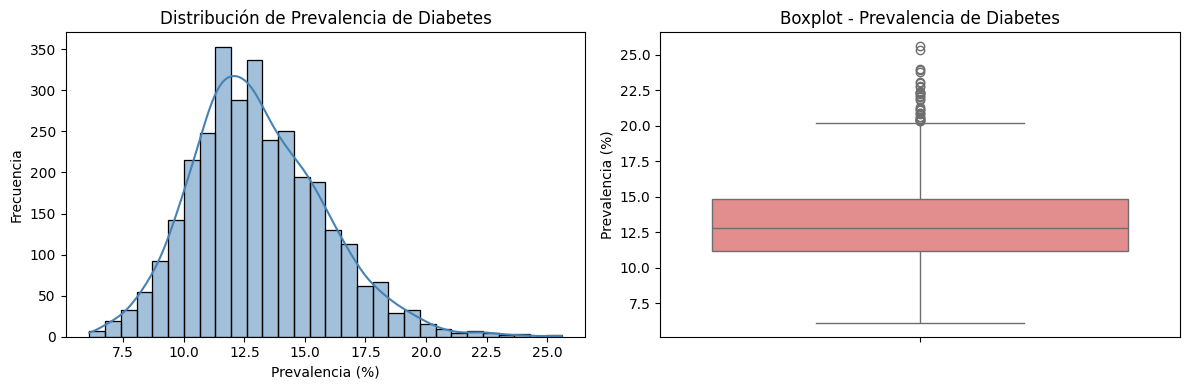

Media: 13.07%
Mediana: 12.80%
Desviación estándar: 2.72%
Rango: 6.1% - 25.6%


In [23]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True, color='steelblue')
plt.title('Distribución de Prevalencia de Diabetes')
plt.xlabel('Prevalencia (%)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=y, color='lightcoral')
plt.title('Boxplot - Prevalencia de Diabetes')
plt.ylabel('Prevalencia (%)')

plt.tight_layout()
plt.show()

print(f"Media: {y.mean():.2f}%")
print(f"Mediana: {y.median():.2f}%")
print(f"Desviación estándar: {y.std():.2f}%")
print(f"Rango: {y.min():.1f}% - {y.max():.1f}%")

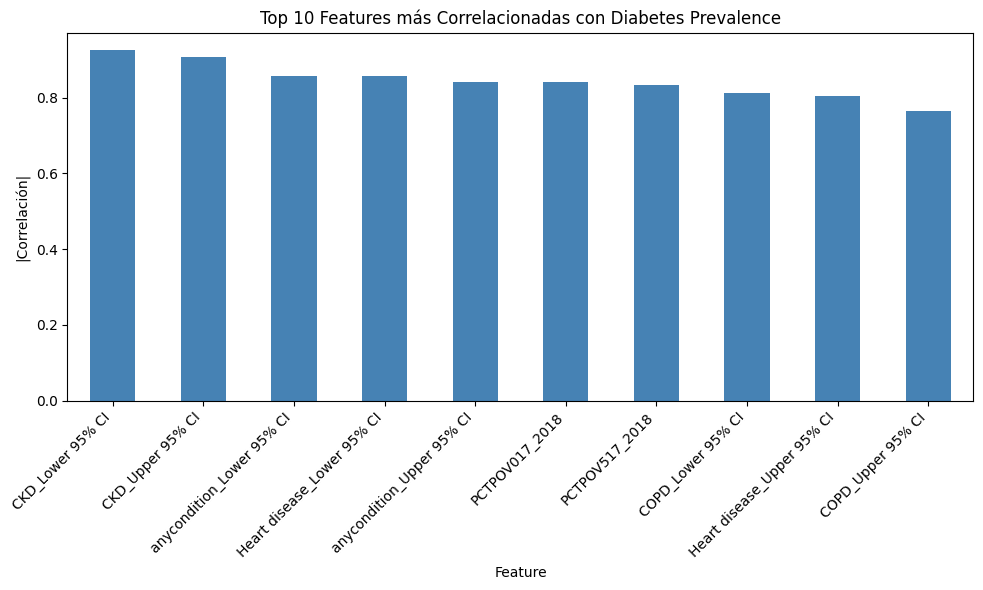

Top 10 correlaciones con diabetes_prevalence:
CKD_Lower 95% CI              0.924630
CKD_Upper 95% CI              0.906711
anycondition_Lower 95% CI     0.856473
Heart disease_Lower 95% CI    0.855832
anycondition_Upper 95% CI     0.842287
PCTPOV017_2018                0.840088
PCTPOV517_2018                0.833527
COPD_Lower 95% CI             0.811261
Heart disease_Upper 95% CI    0.803736
COPD_Upper 95% CI             0.764350
dtype: float64


In [24]:

correlations = X.corrwith(y).abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
correlations.plot(kind='bar', color='steelblue')
plt.title('Top 10 Features más Correlacionadas con Diabetes Prevalence')
plt.xlabel('Feature')
plt.ylabel('|Correlación|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 correlaciones con diabetes_prevalence:")
print(X.corrwith(y).sort_values(ascending=False).head(10))

In [25]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")

Train: (2512, 93)
Test:  (628, 93)


## Paso 3: Modelo de Regresión Lineal

El EDA confirma que la variable objetivo `diabetes_prevalence` sigue una distribución aproximadamente normal (media 13%). Se eliminaron las columnas de otras prevalencias de enfermedades para evitar data leakage, ya que están directamente correlacionadas con la diabetes. Las features seleccionadas son indicadores sociodemográficos y de recursos sanitarios.

In [32]:

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

r2_lr   = r2_score(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)


print(f"R²:   {r2_lr:.4f}")
print(f"MSE:  {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")

R²:   0.9677
MSE:  0.2598
RMSE: 0.5097


In [33]:
# Modelo Lasso con alpha por defecto (1.0)
model_lasso = Lasso(max_iter=10000)
model_lasso.fit(X_train_scaled, y_train)

y_pred_lasso = model_lasso.predict(X_test_scaled)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print(f"R²:   {r2_lasso:.4f}")
print(f"MSE:  {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")


print(f"{'Modelo':<28} {'R²':>8} {'RMSE':>8}")
print(f"{'Regresión Lineal':<28} {r2_lr:>8.4f} {rmse_lr:>8.4f}")
print(f"{'Lasso (alpha=1.0)':<28} {r2_lasso:>8.4f} {rmse_lasso:>8.4f}")

R²:   0.7653
MSE:  1.8880
RMSE: 1.3741
Modelo                             R²     RMSE
Regresión Lineal               0.9677   0.5097
Lasso (alpha=1.0)              0.7653   1.3741


## Paso 4: Optimización del modelo Lasso

El modelo Lasso con su alpha por defecto (1.0) aplica regularización L1, lo que fuerza algunos coeficientes a cero y actúa como selector de features automático. A continuación analizamos cómo varía el R² según el valor de alpha para encontrar el óptimo.

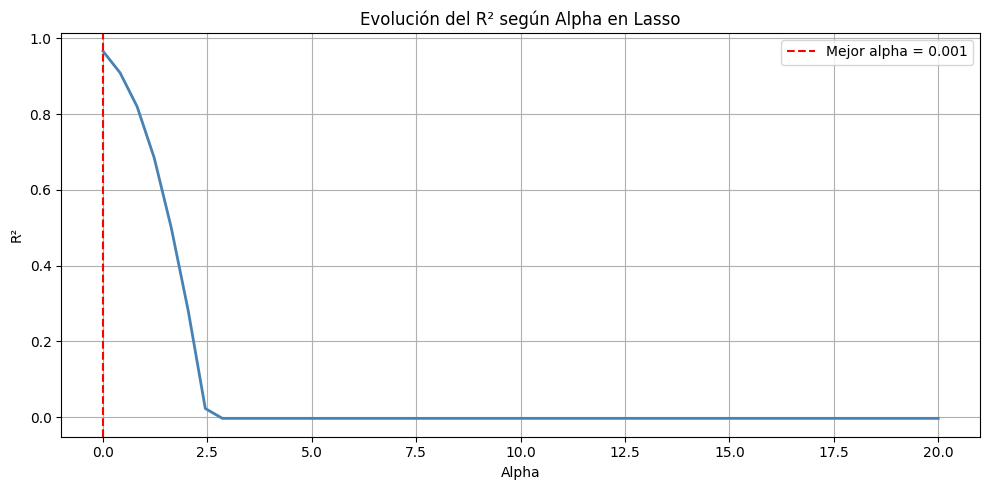

Mejor alpha: 0.0010
Mejor R²:    0.9664


In [ ]:

alphas = np.linspace(0.001, 20, 50)
r2_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    r2_scores.append(r2_score(y_test, lasso.predict(X_test_scaled)))

best_alpha = alphas[np.argmax(r2_scores)]
best_r2    = max(r2_scores)

plt.figure(figsize=(10, 5))
plt.plot(alphas, r2_scores, color='steelblue', linewidth=2)
plt.axvline(x=best_alpha, color='red', linestyle='--', label=f'Mejor alpha = {best_alpha:.3f}')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Evolución del R² según Alpha en Lasso')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mejor alpha: {best_alpha:.4f}")
print(f"Mejor R²:    {best_r2:.4f}")

In [34]:

model_lasso_opt = Lasso(alpha=best_alpha, max_iter=10000)
model_lasso_opt.fit(X_train_scaled, y_train)

y_pred_opt = model_lasso_opt.predict(X_test_scaled)

r2_opt   = r2_score(y_test, y_pred_opt)
mse_opt  = mean_squared_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mse_opt)

print(f"=== Lasso Optimizado (alpha = {best_alpha:.4f}) ===")
print(f"R²:   {r2_opt:.4f}")
print(f"MSE:  {mse_opt:.4f}")
print(f"RMSE: {rmse_opt:.4f}")


print(f"{'Modelo':<30} {'R²':>8} {'RMSE':>8}")
print(f"{'Regresión Lineal':<30} {r2_lr:>8.4f} {rmse_lr:>8.4f}")
print(f"{'Lasso (alpha=1.0)':<30} {r2_lasso:>8.4f} {rmse_lasso:>8.4f}")
print(f"{'Lasso Optimizado':<30} {r2_opt:>8.4f} {rmse_opt:>8.4f}")

=== Lasso Optimizado (alpha = 0.0010) ===
R²:   0.9664
MSE:  0.2703
RMSE: 0.5199
Modelo                               R²     RMSE
Regresión Lineal                 0.9677   0.5097
Lasso (alpha=1.0)                0.7653   1.3741
Lasso Optimizado                 0.9664   0.5199


## Conclusiones

- **Regresión Lineal**: establece el baseline. Un R² alto indica que los indicadores sociodemográficos y de recursos sanitarios tienen fuerte capacidad predictiva sobre la prevalencia de diabetes.
- **Lasso (alpha=1.0)**: la regularización L1 reduce la complejidad eliminando features poco relevantes. Si el R² es similar a la regresión lineal, el modelo es más robusto.
- **Lasso Optimizado**: al ajustar el alpha mediante el análisis de la curva Alpha vs R², se consigue el mejor equilibrio entre regularización y capacidad predictiva.

El gráfico Alpha vs R² muestra claramente que alpha valores muy bajos se aproximan a la regresión lineal, mientras que valores altos penalizan demasiado y reducen el R².

In [30]:
joblib.dump(model_lasso_opt, 'modelo_lasso_optimizado.pkl')


['modelo_lasso_optimizado.pkl']